In [ ]:
### <div class="alert alert-block alert-info"><b>Import library<b><div>


In [20]:
# ==========================================
# IMPORT LIBRARIES
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

print("Libraries imported")

Libraries imported


In [ ]:
### <div class="alert alert-block alert-info"><b>Load Dataset <b><div>


In [21]:

# Load Cleaned matche dataset
match_level=pd.read_csv( r"C:\Users\Akash\Downloads\Dataset\matches_cleaned.csv")

# Load Cleaned ipl_data dataset
ipl_data=pd.read_csv( r"C:\Users\Akash\Downloads\Dataset\ipl_dataset_cleaned.csv",low_memory=False)



In [ ]:
### <div class="alert alert-block alert-info"><b>Dashboard-1 — Best Batter Intelligence<b><div>


In [22]:
# ==========================================
# BATTER METRICS SUMMARY
# ==========================================

# Total Runs

batter_runs = ipl_data.groupby(
    "batter"
)["batsman_runs"].sum()


# Matches Played

batter_matches = ipl_data.groupby(
    "batter"
)["match_id"].nunique()


# Balls Faced

batter_balls = ipl_data.groupby(
    "batter"
)["ball"].count()


# Times Out

batter_outs = ipl_data[
    ipl_data["player_dismissed"] != "Not Out"
].groupby(
    "batter"
)["player_dismissed"].count()


# Strike Rate

strike_rate = (
    batter_runs /
    batter_balls
) * 100


# Batting Average

batting_average = (
    batter_runs /
    batter_outs
)


# Runs per Match

runs_per_match = (
    batter_runs /
    batter_matches
)


# Combine

batter_stats = pd.DataFrame({

    "Runs": batter_runs,
    "Matches": batter_matches,
    "Strike Rate": strike_rate,
    "Average": batting_average,
    "Runs per Match": runs_per_match

})


# Filter reliable batters

batter_stats = batter_stats[
    batter_stats["Matches"] >= 30
]

batter_stats.head(10)

,Runs,Matches,Strike Rate,Average,Runs per Match
batter,,,,,
A Badoni,598,35,125.630252,26.000000,17.085714
A Mishra,366,54,86.729858,12.620690,6.777778
A Symonds,939,36,125.033289,37.560000,26.083333
AB de Villiers,5007,170,147.481591,40.707317,29.452941
AC Gilchrist,1983,80,132.819826,26.092105,24.787500
AD Mathews,706,41,122.357019,23.533333,17.219512
AD Russell,2307,104,162.236287,28.134146,22.182692
AJ Finch,2006,90,122.766218,24.765432,22.288889
AK Markram,958,42,125.557012,30.903226,22.809524


In [23]:
# ==========================================
# BATTER PERFORMANCE SCORE
# ==========================================

# Normalize metrics

batter_stats["Runs_norm"] = (
    batter_stats["Runs"] /
    batter_stats["Runs"].max()
)

batter_stats["SR_norm"] = (
    batter_stats["Strike Rate"] /
    batter_stats["Strike Rate"].max()
)

batter_stats["Avg_norm"] = (
    batter_stats["Average"] /
    batter_stats["Average"].max()
)


# Weighted Score

batter_stats["Performance Score"] = (

    0.4 * batter_stats["Runs_norm"]

    +

    0.3 * batter_stats["SR_norm"]

    +

    0.3 * batter_stats["Avg_norm"]

)


top_batters_final = batter_stats.sort_values(

    by="Performance Score",

    ascending=False

).head(10)


top_batters_final

,Runs,Matches,Strike Rate,Average,Runs per Match,Runs_norm,SR_norm,Avg_norm,Performance Score
batter,,,,,,,,,
V Kohli,7826,243,129.248555,37.090047,32.205761,1.000000,0.796669,0.830556,0.888168
DA Warner,6382,184,136.309270,39.639752,34.684783,0.815487,0.840190,0.887652,0.844547
AB de Villiers,5007,170,147.481591,40.707317,29.452941,0.639790,0.909054,0.911558,0.802100
S Dhawan,6603,221,124.116541,34.936508,29.877828,0.843726,0.765036,0.782332,0.801701
KL Rahul,4555,122,131.003739,44.656863,37.336066,0.582034,0.807487,1.000000,0.775060
CH Gayle,4719,141,140.362879,38.056452,33.468085,0.602990,0.865176,0.852197,0.756408
RG Sharma,6427,251,127.393459,27.943478,25.605578,0.821237,0.785234,0.625738,0.751786
SK Raina,5343,200,132.317979,32.981481,26.715000,0.682724,0.815588,0.738553,0.739332
MS Dhoni,5002,227,132.363059,35.475177,22.035242,0.639152,0.815866,0.794395,0.738739


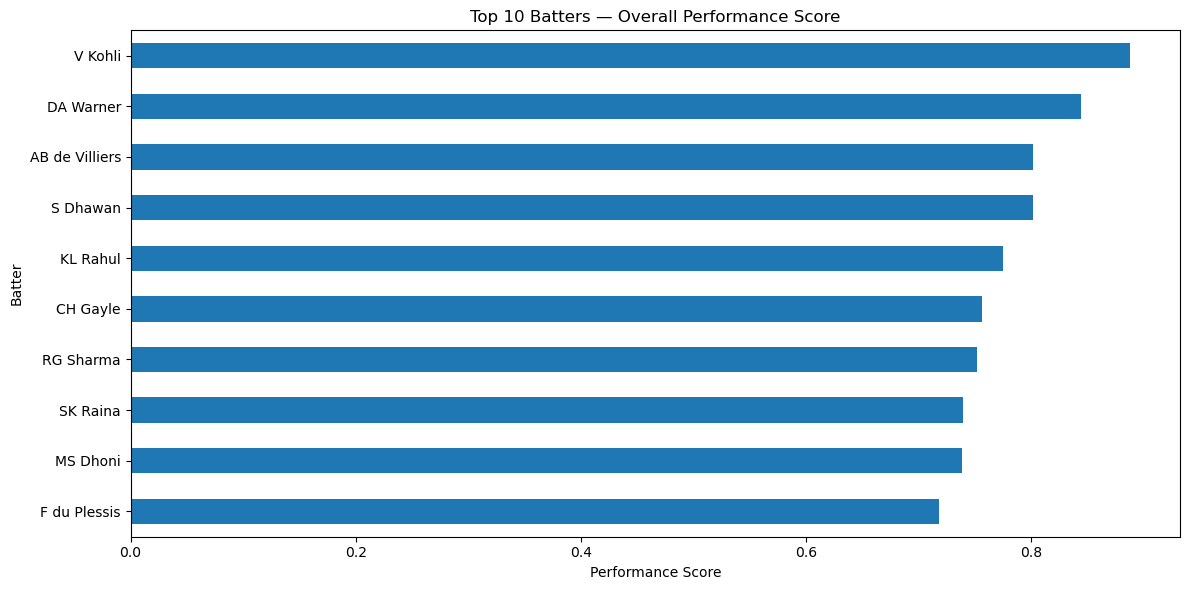

In [48]:
# ==========================================
# TOP BATTER VISUALIZATION
# ==========================================

plt.figure(figsize=(12,6))

top_batters_final[
    "Performance Score"
].sort_values().plot(

    kind="barh"

)

plt.title(
    "Top 10 Batters — Overall Performance Score"
)

plt.xlabel("Performance Score")

plt.ylabel("Batter")

plt.tight_layout()
plt.savefig(
    "top_batters_chart.png"
)
plt.show()

In [25]:
top_batters_final.head()

,Runs,Matches,Strike Rate,Average,Runs per Match,Runs_norm,SR_norm,Avg_norm,Performance Score
batter,,,,,,,,,
V Kohli,7826,243,129.248555,37.090047,32.205761,1.000000,0.796669,0.830556,0.888168
DA Warner,6382,184,136.309270,39.639752,34.684783,0.815487,0.840190,0.887652,0.844547
AB de Villiers,5007,170,147.481591,40.707317,29.452941,0.639790,0.909054,0.911558,0.802100
S Dhawan,6603,221,124.116541,34.936508,29.877828,0.843726,0.765036,0.782332,0.801701
KL Rahul,4555,122,131.003739,44.656863,37.336066,0.582034,0.807487,1.000000,0.775060


In [ ]:
### <div class="alert alert-block alert-info"><b>Dashboard-2 — Best Bowler Intelligence<b><div>


In [26]:
# ==========================================
# BOWLER METRICS SUMMARY
# ==========================================

# Total wickets

bowler_wickets = ipl_data[

    ipl_data["is_wicket"] == 1

].groupby(
    "bowler"
)["is_wicket"].count()


# Runs conceded

bowler_runs = ipl_data.groupby(
    "bowler"
)["total_runs"].sum()


# Balls bowled

bowler_balls = ipl_data.groupby(
    "bowler"
)["ball"].count()


# Overs bowled

bowler_overs = bowler_balls / 6


# Matches played

bowler_matches = ipl_data.groupby(
    "bowler"
)["match_id"].nunique()

In [27]:
# ==========================================
# ECONOMY & AVERAGE
# ==========================================

# Economy Rate

economy = (
    bowler_runs /
    bowler_overs
)


# Bowling Average

bowling_average = (
    bowler_runs /
    bowler_wickets
)


# Wickets per Match

wickets_per_match = (
    bowler_wickets /
    bowler_matches
)

In [28]:
# ==========================================
# COMBINE BOWLER METRICS
# ==========================================

bowler_stats = pd.DataFrame({

    "Wickets": bowler_wickets,

    "Matches": bowler_matches,

    "Economy": economy,

    "Average": bowling_average,

    "Wickets per Match": wickets_per_match

})


# Filter reliable bowlers

bowler_stats = bowler_stats[

    bowler_stats["Matches"] >= 30

]


bowler_stats.head()

,Wickets,Matches,Economy,Average,Wickets per Match
bowler,,,,,
A Kumble,48.0,42,6.652174,22.312500,1.142857
A Mishra,179.0,162,7.350934,23.072626,1.104938
A Nehra,113.0,88,7.804086,21.973451,1.284091
A Nortje,59.0,46,8.866351,26.423729,1.282609
A Symonds,23.0,30,7.730550,29.521739,0.766667


In [29]:
# ==========================================
# NORMALIZE METRICS
# ==========================================

bowler_stats["Wickets_norm"] = (

    bowler_stats["Wickets"] /

    bowler_stats["Wickets"].max()

)


bowler_stats["Eco_norm"] = (

    bowler_stats["Economy"].min() /

    bowler_stats["Economy"]

)


bowler_stats["Avg_norm"] = (

    bowler_stats["Average"].min() /

    bowler_stats["Average"]

)

In [30]:
# ==========================================
# BOWLER PERFORMANCE SCORE
# ==========================================

bowler_stats["Performance Score"] = (

    0.4 * bowler_stats["Wickets_norm"]

    +

    0.3 * bowler_stats["Eco_norm"]

    +

    0.3 * bowler_stats["Avg_norm"]

)


top_bowlers_final = bowler_stats.sort_values(

    by="Performance Score",

    ascending=False

).head(10)


top_bowlers_final


,Wickets,Matches,Economy,Average,Wickets per Match,Wickets_norm,Eco_norm,Avg_norm,Performance Score
bowler,,,,,,,,,
SL Malinga,180.0,122,7.020509,18.383333,1.475410,0.891089,0.947534,1.000000,0.940696
SP Narine,197.0,175,6.777560,23.406091,1.125714,0.975248,0.981500,0.785408,0.920171
JJ Bumrah,179.0,133,7.135241,20.435754,1.345865,0.886139,0.932298,0.899567,0.904015
YS Chahal,202.0,159,7.736439,22.475248,1.270440,1.000000,0.859850,0.817937,0.903336
DJ Bravo,197.0,158,8.110755,21.436548,1.246835,0.975248,0.820167,0.857570,0.893420
A Mishra,179.0,162,7.350934,23.072626,1.104938,0.886139,0.904943,0.796759,0.864966
R Ashwin,191.0,208,6.972149,27.523560,0.918269,0.945545,0.954107,0.667913,0.864824
PP Chawla,199.0,191,8.002077,25.809045,1.041885,0.985149,0.831306,0.712283,0.857136
B Kumar,186.0,176,7.457428,26.134409,1.056818,0.920792,0.892020,0.703415,0.846947


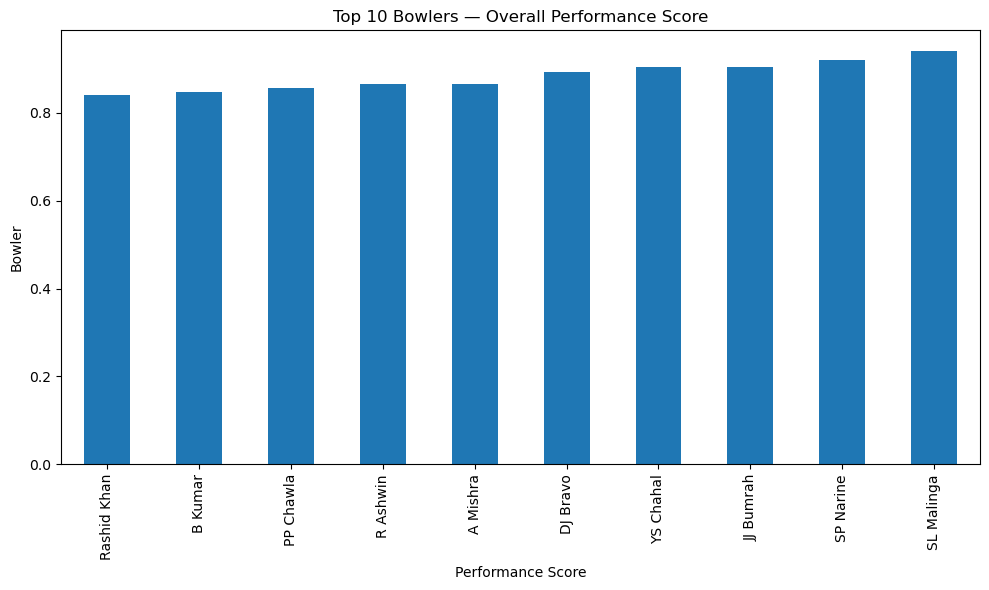

In [31]:
# ==========================================
# TOP BOWLERS VISUALIZATION
# ==========================================

plt.figure(figsize=(10,6))

top_bowlers_final[
    "Performance Score"
].sort_values().plot(

    kind="bar"

)

plt.title(

    "Top 10 Bowlers — Overall Performance Score"

)

plt.xlabel("Performance Score")

plt.ylabel("Bowler")

plt.tight_layout()

plt.show()

In [32]:
top_bowlers_final.head()

,Wickets,Matches,Economy,Average,Wickets per Match,Wickets_norm,Eco_norm,Avg_norm,Performance Score
bowler,,,,,,,,,
SL Malinga,180.0,122,7.020509,18.383333,1.475410,0.891089,0.947534,1.000000,0.940696
SP Narine,197.0,175,6.777560,23.406091,1.125714,0.975248,0.981500,0.785408,0.920171
JJ Bumrah,179.0,133,7.135241,20.435754,1.345865,0.886139,0.932298,0.899567,0.904015
YS Chahal,202.0,159,7.736439,22.475248,1.270440,1.000000,0.859850,0.817937,0.903336
DJ Bravo,197.0,158,8.110755,21.436548,1.246835,0.975248,0.820167,0.857570,0.893420


In [ ]:
### <div class="alert alert-block alert-info"><b>Dashboard-3 — Venue Strategy Intelligence <b><div>


In [33]:
# ==========================================
# VENUE POPULARITY
# ==========================================

# Match-level dataset

match_level = ipl_data.drop_duplicates(
    subset="match_id"
)

# Count matches per venue

venue_popularity = match_level.groupby(
    "venue"
)["match_id"].count()

# Sort by popularity

venue_popularity = venue_popularity.sort_values(
    ascending=False
)

venue_popularity.head(10)

venue
Wankhede Stadium, Mumbai                                  118
M. Chinnaswamy Stadium, Bengaluru                          94
Eden Gardens, Kolkata                                      93
MA Chidambaram Stadium, Chepauk, Chennai                   85
Rajiv Gandhi International Stadium, Uppal, Hyderabad       77
I.S. Bindra Punjab Cricket Association Stadium, Mohali     61
Feroz Shah Kotla                                           60
Sawai Mansingh Stadium, Jaipur                             57
Dubai International Cricket Stadium                        46
Dr DY Patil Sports Academy, Mumbai                         37
Name: match_id, dtype: int64

In [34]:
# ==========================================
# AVERAGE RUNS PER VENUE
# ==========================================

match_runs = ipl_data.groupby(
    ["match_id", "venue"]
)["total_runs"].sum().reset_index()

venue_avg_runs = match_runs.groupby(
    "venue"
)["total_runs"].mean()

venue_avg_runs.head()

venue
Arun Jaitley Stadium, Delhi                                              339.933333
Barabati Stadium                                                         319.285714
Barsapara Cricket Stadium, Guwahati                                      329.333333
Bharat Ratna Shri Atal Bihari Vajpayee Ekana Cricket Stadium, Lucknow    293.857143
Brabourne Stadium, Mumbai                                                329.370370
Name: total_runs, dtype: float64

In [35]:
# ==========================================
# TOSS DECISION PER VENUE
# ==========================================

venue_toss = match_level.groupby(
    ["venue", "toss_decision"]
)["match_id"].count().unstack()

venue_toss_percent = venue_toss.div(
    venue_toss.sum(axis=1),
    axis=0
) * 100

venue_toss_percent.head()

toss_decision,bat,field
venue,,
"Arun Jaitley Stadium, Delhi",33.333333,66.666667
Barabati Stadium,28.571429,71.428571
"Barsapara Cricket Stadium, Guwahati",33.333333,66.666667
"Bharat Ratna Shri Atal Bihari Vajpayee Ekana Cricket Stadium, Lucknow",42.857143,57.142857
"Brabourne Stadium, Mumbai",33.333333,66.666667


In [36]:
# ==========================================
# COMBINE VENUE METRICS
# ==========================================

venue_summary = pd.DataFrame({

    "Matches": venue_popularity,

    "Avg Runs": venue_avg_runs

})

# Add toss preference

venue_summary["Field First %"] = venue_toss_percent[
    "field"
]

venue_summary["Bat First %"] = venue_toss_percent[
    "bat"
]

venue_summary.head()

,Matches,Avg Runs,Field First %,Bat First %
venue,,,,
"Arun Jaitley Stadium, Delhi",30,339.933333,66.666667,33.333333
Barabati Stadium,7,319.285714,71.428571,28.571429
"Barsapara Cricket Stadium, Guwahati",3,329.333333,66.666667,33.333333
"Bharat Ratna Shri Atal Bihari Vajpayee Ekana Cricket Stadium, Lucknow",14,293.857143,57.142857,42.857143
"Brabourne Stadium, Mumbai",27,329.370370,66.666667,33.333333


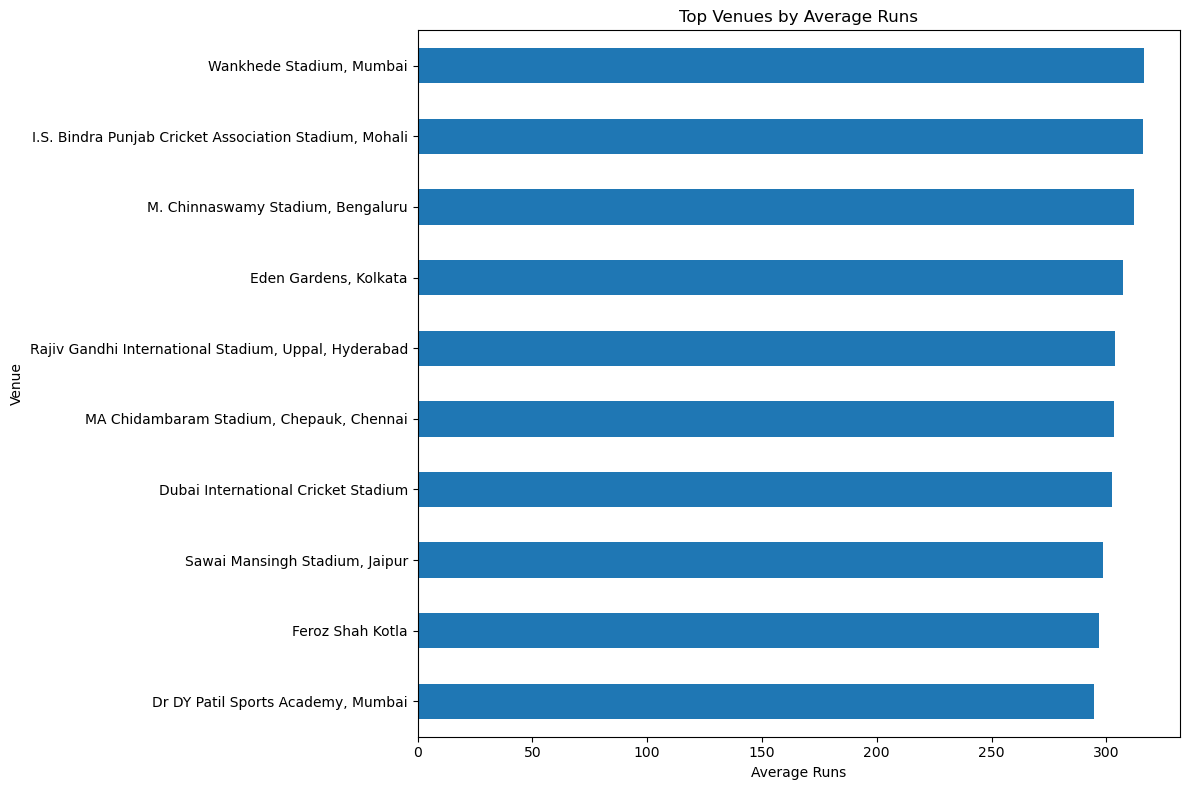

In [37]:
# ==========================================
# TOP VENUE STRATEGY
# ==========================================

top_venues = venue_summary.sort_values(
    by="Matches",
    ascending=False
).head(10)


plt.figure(figsize=(12,8))

top_venues["Avg Runs"].sort_values().plot(
    kind="barh"
)

plt.title(
    "Top Venues by Average Runs"
)

plt.xlabel("Average Runs")

plt.ylabel("Venue")

plt.tight_layout()

plt.show()

In [38]:
venue_summary.head()

,Matches,Avg Runs,Field First %,Bat First %
venue,,,,
"Arun Jaitley Stadium, Delhi",30,339.933333,66.666667,33.333333
Barabati Stadium,7,319.285714,71.428571,28.571429
"Barsapara Cricket Stadium, Guwahati",3,329.333333,66.666667,33.333333
"Bharat Ratna Shri Atal Bihari Vajpayee Ekana Cricket Stadium, Lucknow",14,293.857143,57.142857,42.857143
"Brabourne Stadium, Mumbai",27,329.370370,66.666667,33.333333


In [44]:
top_venues = venue_summary.sort_values(
    by="Matches",
    ascending=False
).head(30)

In [45]:
# ==========================================
# SAVE FINAL OUTPUT TABLES
# ==========================================

top_batters_final.to_csv(
    "top_batters_summary.csv",
    index=True
)

top_bowlers_final.to_csv(
    "top_bowlers_summary.csv",
    index=True
)

top_venues.to_csv(
    "venue_strategy_summary.csv",
    index=True
)

# phase_summary.to_csv(
#     "match_phase_summary.csv",
#     index=True
# )

print("All summary files saved successfully")

All summary files saved successfully


In [47]:
plt.savefig("top_batters_chart.png")

<Figure size 640x480 with 0 Axes>